In [2]:
!pip install tensorflow scikit-learn matplotlib numpy

In [3]:
# Deep Learning Library
import tensorflow as tf
from tensorflow.keras import layers, models

# Dataset Loader
from sklearn.datasets import fetch_lfw_people

# Train-Test Split
from sklearn.model_selection import train_test_split

# Visualization
import matplotlib.pyplot as plt

# Numerical Operations
import numpy as np

In [4]:
print("Loading Dataset...")

# Load dataset
lfw_people = fetch_lfw_people(
    min_faces_per_person=70,
    resize=0.4
)

Loading Dataset...


In [5]:
# Images
X = lfw_people.images

# Labels
y = lfw_people.target

# Person Names
target_names = lfw_people.target_names

# Number of people/classes
n_classes = len(target_names)

In [6]:
print("Total Images :", X.shape[0])
print("Image Height :", X.shape[1])
print("Image Width  :", X.shape[2])

print("\nTotal Classes :", n_classes)

print("\nPeople Names :")
print(target_names)

Total Images : 1288
Image Height : 50
Image Width  : 37

Total Classes : 7

People Names :
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


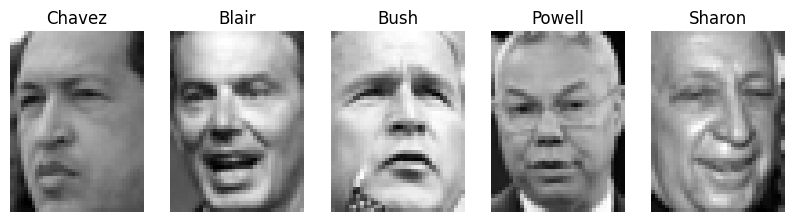

In [7]:
plt.figure(figsize=(10, 5))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(X[i], cmap='gray')

    plt.title(target_names[y[i]].split()[-1])

    plt.axis('off')

plt.show()

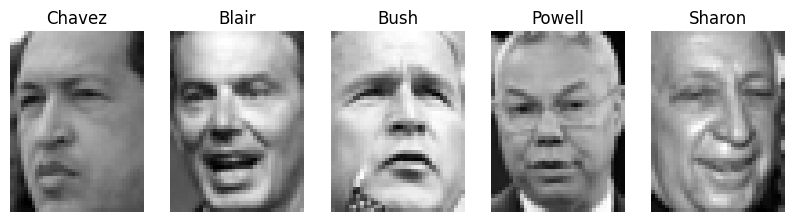

In [8]:
plt.figure(figsize=(10, 5))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(X[i], cmap='gray')

    plt.title(target_names[y[i]].split()[-1])

    plt.axis('off')

plt.show()

In [11]:
print(f"Original shape of X: {X.shape}")

Original shape of X: (1288, 50, 37)


In [12]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    X.shape[2],
    1
)

In [13]:
X = X / 255.0

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [15]:
model = models.Sequential([

    # First Convolution Layer
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(X.shape[1], X.shape[2], 1)
    ),

    # First Pooling Layer
    layers.MaxPooling2D((2, 2)),


    # Second Convolution Layer
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    # Second Pooling Layer
    layers.MaxPooling2D((2, 2)),


    # Third Convolution Layer
    layers.Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    # Third Pooling Layer
    layers.MaxPooling2D((2, 2)),


    # Convert 2D data to 1D
    layers.Flatten(),


    # Fully Connected Layer
    layers.Dense(
        256,
        activation='relu'
    ),


    # Prevent Overfitting
    layers.Dropout(0.5),


    # Output Layer
    layers.Dense(
        n_classes,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 35, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,871 (1.36 MB)

 Trainable params: 356,871 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
print("Training Started...")

history = model.fit(
    X_train,
    y_train,

    epochs=30,

    batch_size=32,

    validation_data=(X_test, y_test)
)

Training Started...
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.3861 - loss: 1.7950 - val_accuracy: 0.4534 - val_loss: 1.6040
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.3975 - loss: 1.7402 - val_accuracy: 0.4534 - val_loss: 1.6057
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.3975 - loss: 1.7274 - val_accuracy: 0.4534 - val_loss: 1.6418
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.3975 - loss: 1.7269 - val_accuracy: 0.4534 - val_loss: 1.6391
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.3975 - loss: 1.7174 - val_accuracy: 0.4534 - val_loss: 1.6453
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.3975 - loss: 1.7351 - val_accuracy: 0.4534 - val_loss: 1.6219
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.3975 - loss: 1.7247 - val_accuracy: 0.4534 - val_loss: 1.6055
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.3975 - loss: 1.7183 - va

In [19]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nFinal Accuracy :", test_accuracy * 100)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4534 - loss: 1.6092

Final Accuracy : 45.34161388874054


In [20]:
predictions = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


In [21]:
def plot_results(images, true_labels, predictions):

    plt.figure(figsize=(15, 6))

    for i in range(10):

        plt.subplot(2, 5, i + 1)

        # Display image
        plt.imshow(
            images[i].reshape(
                X.shape[1],
                X.shape[2]
            ),
            cmap='gray'
        )

        # Predicted label
        predicted_label = np.argmax(predictions[i])

        # True label
        true_label = true_labels[i]

        # Green if correct else red
        color = "green" if predicted_label == true_label else "red"

        plt.title(
            f"Pred: {target_names[predicted_label].split()[-1]}\n"
            f"True: {target_names[true_label].split()[-1]}",
            color=color,
            fontsize=10
        )

        plt.axis('off')

    plt.tight_layout()
    plt.show()

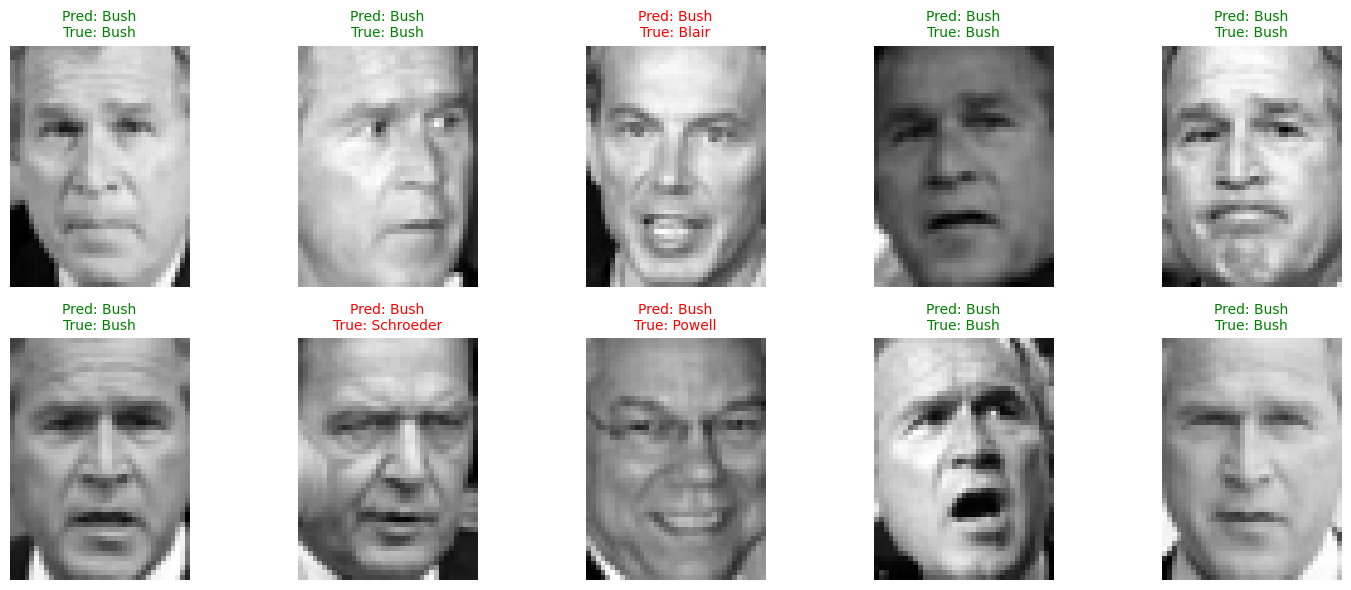

In [22]:
plot_results(
    X_test,
    y_test,
    predictions
)